<a href="https://colab.research.google.com/github/HEM2058/remotesening-app/blob/main/biomass_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Sentinel2_Biomass_Indices_WithCoords_2018.csv to Sentinel2_Biomass_Indices_WithCoords_2018 (1).csv


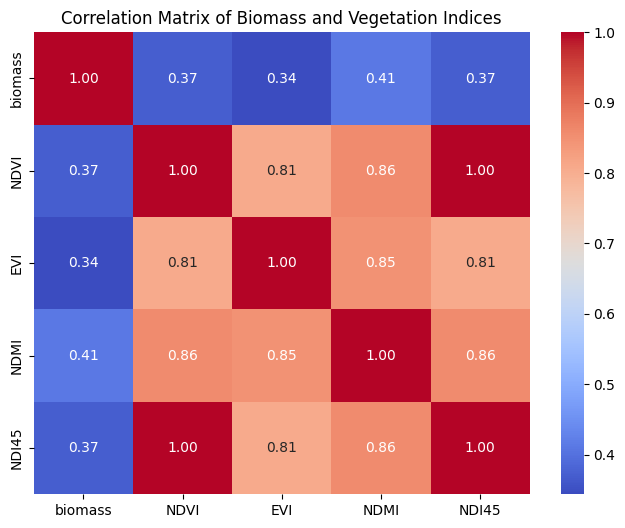

In [ ]:
# Step 1: Upload the CSV file
from google.colab import files
uploaded = files.upload()

# Step 2: Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Load the dataset
# Replace the filename with the one you've uploaded if it's different
df = pd.read_csv('/content/Sentinel2_Biomass_Indices_WithCoords_2018.csv')

# Step 4: Drop latitude and longitude
df_filtered = df.drop(['latitude', 'longitude'], axis=1)

# Step 5: Compute the correlation matrix
correlation_matrix = df_filtered.corr()

# Step 6: Display the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Biomass and Vegetation Indices')
plt.show()


Saving Biomass_Indices_2018.csv to Biomass_Indices_2018.csv


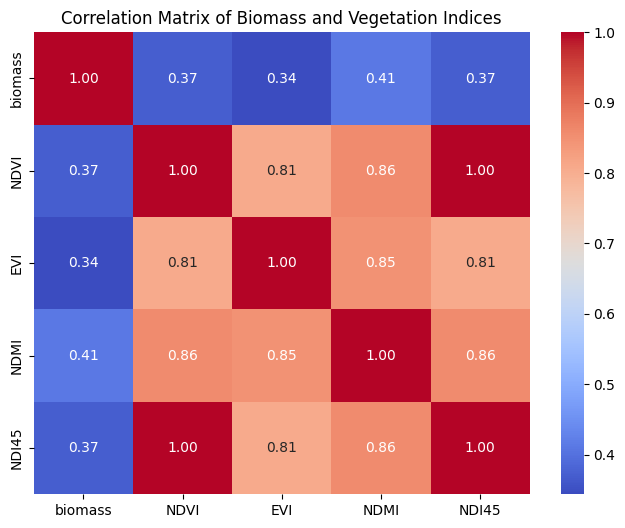

In [4]:
# Step 1: Upload the CSV file
from google.colab import files
uploaded = files.upload()

# Step 2: Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Load the dataset
# Replace the filename with the one you've uploaded if it's different
df = pd.read_csv('/content/Sentinel2_Biomass_Indices_WithCoords_2018.csv')

# Step 4: Drop rows with empty index values
df_cleaned = df.dropna()

# Step 5: Drop latitude and longitude
df_filtered = df_cleaned.drop(['latitude', 'longitude'], axis=1)

# Step 6: Compute the correlation matrix
correlation_matrix = df_filtered.corr()

# Step 7: Display the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Biomass and Vegetation Indices')
plt.show()


Top 10 index combinations correlated with biomass:
NDMI            0.411817
NDVI+NDMI       0.403670
NDMI+NDI45      0.403670
NDVI*NDMI       0.402380
NDMI*NDI45      0.402380
EVI+NDMI        0.395829
mean_indices    0.393985
EVI*NDMI        0.380648
NDVI+EVI        0.376934
EVI+NDI45       0.376934
Name: biomass, dtype: float64


<ipython-input-5-6e5fa6851793>:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")


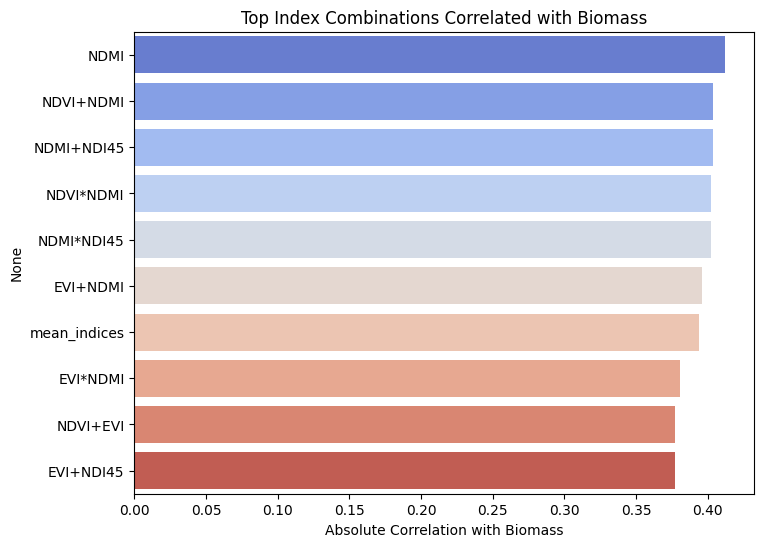

In [5]:
# Step 1: Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load the dataset
df = pd.read_csv('/content/Sentinel2_Biomass_Indices_WithCoords_2018.csv')

# Step 3: Clean dataset (drop NaNs and coordinates)
df_cleaned = df.dropna()
df_filtered = df_cleaned.drop(['latitude', 'longitude'], axis=1)

# Step 4: Extract indices names
indices = ['NDVI', 'EVI', 'NDMI', 'NDI45']

# Step 5: Create combinations
df_comb = df_filtered.copy()

# Sum of pairs
for i in range(len(indices)):
    for j in range(i+1, len(indices)):
        df_comb[f'{indices[i]}+{indices[j]}'] = df_filtered[indices[i]] + df_filtered[indices[j]]

# Product of pairs
for i in range(len(indices)):
    for j in range(i+1, len(indices)):
        df_comb[f'{indices[i]}*{indices[j]}'] = df_filtered[indices[i]] * df_filtered[indices[j]]

# Ratio of pairs (avoid division by zero)
for i in range(len(indices)):
    for j in range(i+1, len(indices)):
        df_comb[f'{indices[i]}/{indices[j]}'] = df_filtered[indices[i]] / (df_filtered[indices[j]] + 1e-6)

# Mean of all indices
df_comb['mean_indices'] = df_filtered[indices].mean(axis=1)

# Step 6: Calculate correlation with biomass
correlations = df_comb.corr()['biomass'].drop('biomass')

# Step 7: Display top 10 combinations
top_corr = correlations.abs().sort_values(ascending=False).head(10)
print("Top 10 index combinations correlated with biomass:")
print(top_corr)

# Optional: Visualize
plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")
plt.xlabel('Absolute Correlation with Biomass')
plt.title('Top Index Combinations Correlated with Biomass')
plt.show()


In [3]:
# Step 1: Upload the CSV file
from google.colab import files
uploaded = files.upload()

# Step 2: Import libraries
import pandas as pd
from itertools import combinations

# Step 3: Load data
df = pd.read_csv('/content/Sentinel2_Biomass_Indices_WithCoords_2018.csv')

# Step 4: Drop latitude and longitude
df_filtered = df.drop(['latitude', 'longitude'], axis=1)

# Step 5: Prepare features and target
X = df_filtered.drop('biomass', axis=1)
y = df_filtered['biomass']

# Step 6: Find best combination
best_corr = -1
best_combo = None
method = 'sum'  # or 'mean' or 'product'

feature_names = X.columns.tolist()

for r in range(1, len(feature_names)+1):
    for combo in combinations(feature_names, r):
        if method == 'sum':
            combined_index = X[list(combo)].sum(axis=1)
        elif method == 'mean':
            combined_index = X[list(combo)].mean(axis=1)
        elif method == 'product':
            combined_index = X[list(combo)].prod(axis=1)

        corr = combined_index.corr(y)

        if abs(corr) > abs(best_corr):  # use absolute correlation
            best_corr = corr
            best_combo = combo

print(f'Best correlation with biomass: {best_corr:.2f}')
print(f'Best combination of indices: {best_combo}')


Saving Sentinel2_Biomass_Indices_WithCoords_2018.csv to Sentinel2_Biomass_Indices_WithCoords_2018 (2).csv
Best correlation with biomass: -1.00
Best combination of indices: None
